In [2]:
!pip uninstall -y torch nvidia-nccl-cu12 nvidia-nccl-cu13
!pip install --no-cache-dir -q vllm==0.28.0 duckdb datasets pandas matplotlib

Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
Found existing installation: nvidia-nccl-cu13 2.29.7
Uninstalling nvidia-nccl-cu13-2.29.7:
  Successfully uninstalled nvidia-nccl-cu13-2.29.7
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 143.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xformers 0.0.32.post1 requires torch==2.8.0, but you have torch 2.13.0 which is incompatible.


In [3]:
import torch
print("torch:", torch.__version__)

import vllm
print("vllm:", vllm.__version__)

torch: 2.13.0+cu130
vllm: 0.28.0


In [4]:
import sys

# Fix 1: Colab's ipykernel stdout lacks .fileno(), which vLLM's
# distributed engine init requires
sys.stdout.fileno = lambda: 1
sys.stderr.fileno = lambda: 2

# Fix 2: torchaudio/PyTorch CUDA version mismatch check
import torch
print("torch:", torch.__version__)
try:
    import torchaudio
    print("torchaudio:", torchaudio.__version__)
except Exception as e:
    print("torchaudio issue (usually harmless for this project):", e)

torch: 2.13.0+cu130
torchaudio: 2.11.0+cu130


In [5]:
import vllm
print("vLLM version:", vllm.__version__)

vLLM version: 0.28.0


In [6]:
from datasets import load_dataset

humaneval = load_dataset("openai/openai_humaneval", split="test")
code_prompts = [humaneval[i]["prompt"] for i in range(10)]

print(f"Loaded {len(code_prompts)} code prompts")
print(code_prompts[0][:200])

Loaded 10 code prompts
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given thr


In [7]:
chat_prompts = []
tool_prompts = []

# --- Chat dataset: confirmed working field names (role='prompter', text=...) ---
try:
    chat_ds = load_dataset("OpenAssistant/oasst1", split="train")
    chat_prompts = [row["text"] for row in chat_ds.select(range(200)) if row.get("role") == "prompter"][:10]
    print(f"chat_prompts loaded: {len(chat_prompts)}")
    print(chat_prompts[0][:200])
except Exception as e:
    print("Chat dataset load failed:", e)

# --- Tool-calling dataset: try xlam first, fall back to hand-written prompts ---
try:
    tool_ds = load_dataset("Salesforce/xlam-function-calling-60k", split="train")
    print("xlam sample record:", tool_ds[0])
    # Inspect the printed record, then adjust the extraction line below to match real field names.
    # Common possibility based on this dataset's known schema:
    tool_prompts = [str(row["query"]) for row in tool_ds.select(range(10))]
    print(f"tool_prompts loaded from xlam: {len(tool_prompts)}")
except Exception as e:
    print("xlam dataset load failed, using hand-written fallback:", e)
    tool_prompts = [
        "Call the weather API to get the current temperature in Tokyo.",
        "Use the search function to find recent news about electric vehicles.",
        "Invoke the calculator tool to compute 347 * 892.",
        "Query the database function to retrieve all users created after 2024-01-01.",
        "Call the send_email function to notify admin@example.com about the deployment.",
        "Use the get_stock_price tool to check the current price of AAPL.",
        "Invoke the translate function to convert 'hello world' to French.",
        "Call the create_calendar_event function for a meeting tomorrow at 3pm.",
        "Use the file_search tool to find all PDFs modified in the last week.",
        "Query the flight_search API for flights from NYC to London next Friday.",
    ]
    print(f"tool_prompts (hand-written fallback): {len(tool_prompts)}")

print(f"\nFinal counts — chat_prompts: {len(chat_prompts)} | tool_prompts: {len(tool_prompts)}")

chat_prompts loaded: 10
Can you write a short introduction about the relevance of the term "monopsony" in economics? Please use examples related to potential monopsonies in the labour market and cite relevant research.
xlam dataset load failed, using hand-written fallback: Dataset 'Salesforce/xlam-function-calling-60k' is a gated dataset on the Hub. Visit the dataset page at https://huggingface.co/datasets/Salesforce/xlam-function-calling-60k to ask for access.
tool_prompts (hand-written fallback): 10

Final counts — chat_prompts: 10 | tool_prompts: 10


In [8]:
task_families = {"code": code_prompts}
if chat_prompts:
    task_families["chat"] = chat_prompts
if tool_prompts:
    task_families["tool_calling"] = tool_prompts

print("Active task families:", list(task_families.keys()))

Active task families: ['code', 'chat', 'tool_calling']


In [9]:
import duckdb, time, gc, torch
from vllm import LLM, SamplingParams

con = duckdb.connect("draftradar_results.db")

con.execute("""
CREATE TABLE IF NOT EXISTS runs (
    run_id INTEGER,
    timestamp TIMESTAMP,
    mode VARCHAR,
    task_family VARCHAR,
    target_model VARCHAR,
    draft_model VARCHAR,
    num_speculative_tokens INTEGER,
    batch_size INTEGER,
    max_tokens INTEGER,
    num_prompts INTEGER,
    wall_time_sec DOUBLE,
    total_output_tokens INTEGER,
    tps DOUBLE,
    num_drafts INTEGER,
    draft_tokens INTEGER,
    accepted_tokens INTEGER,
    acceptance_rate DOUBLE,
    mean_acceptance_length DOUBLE,
    mean_ttft_sec DOUBLE,
    mean_e2e_latency_sec DOUBLE,
    mean_decode_time_sec DOUBLE,
    prefix_cache_hit_rate DOUBLE
)
""")

run_counter = [0]

def get_metric(metrics, name):
    return [m for m in metrics if m.name == name]

def safe_metric(metrics, name, field="value"):
    matches = get_metric(metrics, name)
    return getattr(matches[0], field) if matches else 0

def snapshot_counters(metrics):
    return {
        "num_drafts": safe_metric(metrics, "vllm:spec_decode_num_drafts"),
        "draft_tokens": safe_metric(metrics, "vllm:spec_decode_num_draft_tokens"),
        "accepted_tokens": safe_metric(metrics, "vllm:spec_decode_num_accepted_tokens"),
        "ttft_sum": safe_metric(metrics, "vllm:time_to_first_token_seconds", "sum"),
        "ttft_count": safe_metric(metrics, "vllm:time_to_first_token_seconds", "count"),
        "e2e_sum": safe_metric(metrics, "vllm:e2e_request_latency_seconds", "sum"),
        "e2e_count": safe_metric(metrics, "vllm:e2e_request_latency_seconds", "count"),
        "decode_sum": safe_metric(metrics, "vllm:request_decode_time_seconds", "sum"),
        "decode_count": safe_metric(metrics, "vllm:request_decode_time_seconds", "count"),
        "cache_q": safe_metric(metrics, "vllm:prefix_cache_queries"),
        "cache_h": safe_metric(metrics, "vllm:prefix_cache_hits"),
    }

def run_and_log(prompt_list, task_family, max_tokens_val, batch_size_label, mode="spec", num_spec_tokens=3, engine=None, target_name=None, draft_name=None):
    before = snapshot_counters(engine.get_metrics())

    sp = SamplingParams(temperature=0.0, max_tokens=max_tokens_val)
    start = time.time()
    outputs = engine.generate(prompt_list, sp)
    elapsed = time.time() - start

    after = snapshot_counters(engine.get_metrics())

    total_output_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
    tps = total_output_tokens / elapsed if elapsed > 0 else 0

    d_drafts = after["num_drafts"] - before["num_drafts"]
    d_draft_tok = after["draft_tokens"] - before["draft_tokens"]
    d_accepted = after["accepted_tokens"] - before["accepted_tokens"]
    acceptance_rate = (d_accepted / d_draft_tok) if d_draft_tok else None
    mean_accept_len = (1 + d_accepted / d_drafts) if d_drafts else None

    d_ttft_sum = after["ttft_sum"] - before["ttft_sum"]
    d_ttft_count = after["ttft_count"] - before["ttft_count"]
    mean_ttft = (d_ttft_sum / d_ttft_count) if d_ttft_count else None

    d_e2e_sum = after["e2e_sum"] - before["e2e_sum"]
    d_e2e_count = after["e2e_count"] - before["e2e_count"]
    mean_e2e = (d_e2e_sum / d_e2e_count) if d_e2e_count else None

    d_decode_sum = after["decode_sum"] - before["decode_sum"]
    d_decode_count = after["decode_count"] - before["decode_count"]
    mean_decode = (d_decode_sum / d_decode_count) if d_decode_count else None

    d_cache_q = after["cache_q"] - before["cache_q"]
    d_cache_h = after["cache_h"] - before["cache_h"]
    cache_rate = (d_cache_h / d_cache_q) if d_cache_q else 0.0

    run_counter[0] += 1
    row = (
        run_counter[0], time.strftime("%Y-%m-%d %H:%M:%S"), mode, task_family,
        target_name, draft_name, num_spec_tokens if mode.startswith("spec") else None,
        batch_size_label, max_tokens_val, len(prompt_list),
        elapsed, total_output_tokens, tps,
        d_drafts, d_draft_tok, d_accepted, acceptance_rate, mean_accept_len,
        mean_ttft, mean_e2e, mean_decode, cache_rate,
    )
    con.execute("INSERT INTO runs VALUES (" + ",".join(["?"] * 22) + ")", row)

    accept_str = f"{acceptance_rate:.3f}" if acceptance_rate is not None else "n/a"
    ttft_str = f"{mean_ttft:.2f}s" if mean_ttft is not None else "n/a"
    print(f"[run {run_counter[0]}] mode={mode} | {task_family} | batch={batch_size_label} | "
          f"max_tokens={max_tokens_val} | TPS={tps:.1f} | accept_rate={accept_str} | TTFT={ttft_str}")
    return row

def load_spec_engine(target, draft, num_spec_tokens=3):
    return LLM(
        model=target, dtype="half",
        speculative_config={"model": draft, "num_speculative_tokens": num_spec_tokens, "method": "draft_model"},
        gpu_memory_utilization=0.75, enforce_eager=True, max_model_len=2048, disable_log_stats=False,
    )

def load_baseline_engine(target):
    return LLM(
        model=target, dtype="half",
        gpu_memory_utilization=0.75, enforce_eager=True, max_model_len=2048, disable_log_stats=False,
    )

def free_engine(engine):
    del engine
    gc.collect()
    torch.cuda.empty_cache()

print("Setup complete.")

Setup complete.


In [11]:
import os, time
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

NARROW_TARGET = "Qwen/Qwen2.5-1.5B-Instruct"
NARROW_DRAFT = "Qwen/Qwen2.5-0.5B-Instruct"

engine = load_spec_engine(NARROW_TARGET, NARROW_DRAFT)
_ = engine.generate(task_families["code"][:1], SamplingParams(temperature=0.0, max_tokens=64))

for task_name, plist in task_families.items():
    run_and_log(plist, task_family=task_name, max_tokens_val=256, batch_size_label=len(plist),
                mode="spec_narrow_gap", engine=engine, target_name=NARROW_TARGET, draft_name=NARROW_DRAFT)

free_engine(engine)
time.sleep(5)
print("Freed narrow_gap spec engine.")

INFO 09-13 17:48:16 [api_utils.py:272] non-default args: {'dtype': 'half', 'max_model_len': 2048, 'gpu_memory_utilization': 0.75, 'enforce_eager': True, 'speculative_config': {'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'num_speculative_tokens': 3, 'method': 'draft_model'}, 'model': 'Qwen/Qwen2.5-1.5B-Instruct'}
INFO 09-13 17:48:16 [model.py:672] Resolved architecture: Qwen2ForCausalLM
WARNING 09-13 17:48:16 [model.py:2299] Casting torch.bfloat16 to torch.float16.
INFO 09-13 17:48:16 [model.py:1965] Using max model len 2048
INFO 09-13 17:48:16 [model.py:672] Resolved architecture: Qwen2ForCausalLM
WARNING 09-13 17:48:16 [model.py:2299] Casting torch.bfloat16 to torch.float16.
INFO 09-13 17:48:16 [model.py:1965] Using max model len 32768
INFO 09-13 17:48:16 [speculative.py:1220] Overriding draft model max model len from 32768 to 2048
INFO 09-13 17:48:16 [kernel.py:308] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_add_rms_norm=[

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:04<00:00,  4.15s/it, est. speed input: 28.45 toks/s, output: 15.43 toks/s]


Rendering prompts:   0%|          | 0/10 [00:00<?, ?it/s]

Processed prompts:  60%|██████    | 6/10 [00:05<00:01,  2.05it/s, est. speed input: 106.46 toks/s, output: 52.89 toks/s]

...

INFO 09-13 17:50:11 [loggers.py:310] Engine 000: Avg prompt throughput: 14.7 tokens/s, Avg generation throughput: 155.9 tokens/s, Running: 10 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.5%, Prefix cache hit rate: 7.2%
INFO 09-13 17:50:11 [metrics.py:120] SpecDecoding metrics: Mean acceptance length: 3.27, Accepted throughput: 108.37 tokens/s, Drafted throughput: 143.40 tokens/s, Accepted: 1095 tokens, Drafted: 1449 tokens, Per-position acceptance rate: 0.845, 0.752, 0.671, Avg Draft acceptance rate: 75.6%


Processed prompts:  40%|████      | 4/10 [00:12<00:23,  3.91s/it, est. speed input: 5.32 toks/s, output: 40.22 toks/s] 

INFO 09-13 17:50:21 [loggers.py:310] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 137.8 tokens/s, Running: 6 reqs, Waiting: 0 reqs, GPU KV cache usage: 1.0%, Prefix cache hit rate: 7.2%
INFO 09-13 17:50:21 [metrics.py:120] SpecDecoding metrics: Mean acceptance length: 3.21, Accepted throughput: 95.16 tokens/s, Drafted throughput: 129.15 tokens/s, Accepted: 966 tokens, Drafted: 1311 tokens, Per-position acceptance rate: 0.844, 0.728, 0.638, Avg Draft acceptance rate: 73.7%


Processed prompts: 100%|██████████| 10/10 [00:18<00:00,  1.81s/it, est. speed input: 8.22 toks/s, output: 111.84 toks/s]


[run 3] mode=spec_narrow_gap | tool_calling | batch=10 | max_tokens=256 | TPS=111.5 | accept_rate=0.721 | TTFT=0.52s
Freed narrow_gap spec engine.


In [12]:
!pip show vllm | grep Version

Version: 0.28.0


In [16]:
del engine
gc.collect()
torch.cuda.empty_cache()

INFO 09-13 17:54:37 [utils.py:615] [shutdown] Process manager: send sigterm to process EngineCore


In [18]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

!nvidia-smi

CUDA available: True
Device count: 1
Sun Sep 13 17:55:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------

In [19]:
engine = load_baseline_engine(NARROW_TARGET)
_ = engine.generate(task_families["code"][:1], SamplingParams(temperature=0.0, max_tokens=64))

for task_name, plist in task_families.items():
    run_and_log(plist, task_family=task_name, max_tokens_val=256, batch_size_label=len(plist),
                mode="baseline_narrow", engine=engine, target_name=NARROW_TARGET)

free_engine(engine)
print("Freed narrow baseline engine.")

INFO 09-13 17:55:25 [api_utils.py:272] non-default args: {'dtype': 'half', 'max_model_len': 2048, 'gpu_memory_utilization': 0.75, 'enforce_eager': True, 'model': 'Qwen/Qwen2.5-1.5B-Instruct'}
INFO 09-13 17:55:25 [model.py:672] Resolved architecture: Qwen2ForCausalLM
WARNING 09-13 17:55:25 [model.py:2299] Casting torch.bfloat16 to torch.float16.
INFO 09-13 17:55:25 [model.py:1965] Using max model len 2048
INFO 09-13 17:55:25 [kernel.py:308] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_add_rms_norm=['vllm_c', 'native'])


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.23s/it, est. speed input: 53.08 toks/s, output: 28.79 toks/s]


Rendering prompts:   0%|          | 0/10 [00:00<?, ?it/s]

Processed prompts:  50%|█████     | 5/10 [00:03<00:02,  1.83it/s, est. speed input: 151.46 toks/s, output: 71.16 toks/s]

...

Rendering prompts:   0%|          | 0/10 [00:00<?, ?it/s]

Processed prompts:  30%|███       | 3/10 [00:04<00:09,  1.34s/it, est. speed input: 11.07 toks/s, output: 52.05 toks/s]

INFO 09-13 17:56:53 [loggers.py:310] Engine 000: Avg prompt throughput: 14.9 tokens/s, Avg generation throughput: 223.6 tokens/s, Running: 7 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.6%, Prefix cache hit rate: 7.2%


Processed prompts: 100%|██████████| 10/10 [00:09<00:00,  1.03it/s, est. speed input: 15.35 toks/s, output: 208.80 toks/s]


[run 6] mode=baseline_narrow | tool_calling | batch=10 | max_tokens=256 | TPS=207.9 | accept_rate=n/a | TTFT=0.19s
Freed narrow baseline engine.


In [20]:
del engine
gc.collect()
torch.cuda.empty_cache()

INFO 09-13 17:57:35 [utils.py:615] [shutdown] Process manager: send sigterm to process EngineCore


In [21]:
import os, time
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

WIDE_TARGET = "Qwen/Qwen2.5-3B-Instruct"
WIDE_DRAFT = "Qwen/Qwen2.5-0.5B-Instruct"

engine = load_spec_engine(WIDE_TARGET, WIDE_DRAFT)
_ = engine.generate(task_families["code"][:1], SamplingParams(temperature=0.0, max_tokens=64))

for task_name, plist in task_families.items():
    run_and_log(plist, task_family=task_name, max_tokens_val=256, batch_size_label=len(plist),
                mode="spec_wide_gap", engine=engine, target_name=WIDE_TARGET, draft_name=WIDE_DRAFT)

free_engine(engine)
print("Freed wide_gap spec engine.")

INFO 09-13 17:59:15 [api_utils.py:272] non-default args: {'dtype': 'half', 'max_model_len': 2048, 'gpu_memory_utilization': 0.75, 'enforce_eager': True, 'speculative_config': {'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'num_speculative_tokens': 3, 'method': 'draft_model'}, 'model': 'Qwen/Qwen2.5-3B-Instruct'}


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

INFO 09-13 17:59:15 [model.py:672] Resolved architecture: Qwen2ForCausalLM
WARNING 09-13 17:59:15 [model.py:2299] Casting torch.bfloat16 to torch.float16.
INFO 09-13 17:59:15 [model.py:1965] Using max model len 2048
INFO 09-13 17:59:16 [model.py:672] Resolved architecture: Qwen2ForCausalLM
WARNING 09-13 17:59:16 [model.py:2299] Casting torch.bfloat16 to torch.float16.
INFO 09-13 17:59:16 [model.py:1965] Using max model len 32768
INFO 09-13 17:59:16 [speculative.py:1220] Overriding draft model max model len from 32768 to 2048
INFO 09-13 17:59:16 [kernel.py:308] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_add_rms_norm=['vllm_c', 'native'])


tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Rendering prompts:   0%|          | 0/10 [00:00<?, ?it/s]

Processed prompts:  10%|█         | 1/10 [00:05<00:49,  5.45s/it, est. speed input: 2.93 toks/s, output: 22.38 toks/s]

INFO 09-13 18:04:40 [loggers.py:310] Engine 000: Avg prompt throughput: 14.7 tokens/s, Avg generation throughput: 168.3 tokens/s, Running: 9 reqs, Waiting: 0 reqs, GPU KV cache usage: 2.9%, Prefix cache hit rate: 7.2%
INFO 09-13 18:04:40 [metrics.py:120] SpecDecoding metrics: Mean acceptance length: 2.75, Accepted throughput: 106.60 tokens/s, Drafted throughput: 183.25 tokens/s, Accepted: 1082 tokens, Drafted: 1860 tokens, Per-position acceptance rate: 0.724, 0.563, 0.458, Avg Draft acceptance rate: 58.2%


Processed prompts: 100%|██████████| 10/10 [00:13<00:00,  1.38s/it, est. speed input: 10.79 toks/s, output: 169.26 toks/s]


[run 9] mode=spec_wide_gap | tool_calling | batch=10 | max_tokens=256 | TPS=168.7 | accept_rate=0.611 | TTFT=0.41s
Freed wide_gap spec engine.


In [22]:
del engine
gc.collect()
torch.cuda.empty_cache()

INFO 09-13 18:05:13 [utils.py:615] [shutdown] Process manager: send sigterm to process EngineCore
WARNING 09-13 18:05:18 [utils.py:635] [shutdown] Process manager: force killing remaining processes count=1
WARNING 09-13 18:05:18 [utils.py:640] [shutdown] Process manager: force killing remaining process EngineCore pid 29841


In [23]:
engine = load_baseline_engine(WIDE_TARGET)
_ = engine.generate(task_families["code"][:1], SamplingParams(temperature=0.0, max_tokens=64))

for task_name, plist in task_families.items():
    run_and_log(plist, task_family=task_name, max_tokens_val=256, batch_size_label=len(plist),
                mode="baseline_wide", engine=engine, target_name=WIDE_TARGET)

free_engine(engine)
print("Freed wide baseline engine.")

INFO 09-13 18:06:01 [api_utils.py:272] non-default args: {'dtype': 'half', 'max_model_len': 2048, 'gpu_memory_utilization': 0.75, 'enforce_eager': True, 'model': 'Qwen/Qwen2.5-3B-Instruct'}
INFO 09-13 18:06:02 [model.py:672] Resolved architecture: Qwen2ForCausalLM
WARNING 09-13 18:06:02 [model.py:2299] Casting torch.bfloat16 to torch.float16.
INFO 09-13 18:06:02 [model.py:1965] Using max model len 2048
INFO 09-13 18:06:02 [kernel.py:308] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_add_rms_norm=['vllm_c', 'native'])


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.43s/it, est. speed input: 48.57 toks/s, output: 23.05 toks/s]


Rendering prompts:   0%|          | 0/10 [00:00<?, ?it/s]

Processed prompts:  60%|██████    | 6/10 [00:04<00:03,  1.33it/s, est. speed input: 140.33 toks/s, output: 73.44 toks/s]

...

Rendering prompts:   0%|          | 0/10 [00:00<?, ?it/s]

Processed prompts:  10%|█         | 1/10 [00:06<00:56,  6.30s/it, est. speed input: 2.54 toks/s, output: 19.36 toks/s]

INFO 09-13 18:08:02 [loggers.py:310] Engine 000: Avg prompt throughput: 14.9 tokens/s, Avg generation throughput: 202.1 tokens/s, Running: 9 reqs, Waiting: 0 reqs, GPU KV cache usage: 1.2%, Prefix cache hit rate: 7.2%


Processed prompts: 100%|██████████| 10/10 [00:12<00:00,  1.22s/it, est. speed input: 12.21 toks/s, output: 191.63 toks/s]


[run 12] mode=baseline_wide | tool_calling | batch=10 | max_tokens=256 | TPS=191.2 | accept_rate=n/a | TTFT=0.15s
Freed wide baseline engine.


In [24]:
del engine
gc.collect()
torch.cuda.empty_cache()

INFO 09-13 18:09:34 [utils.py:615] [shutdown] Process manager: send sigterm to process EngineCore
WARNING 09-13 18:09:39 [utils.py:635] [shutdown] Process manager: force killing remaining processes count=1
WARNING 09-13 18:09:39 [utils.py:640] [shutdown] Process manager: force killing remaining process EngineCore pid 31729


In [25]:
engine = load_spec_engine(WIDE_TARGET, WIDE_DRAFT)
_ = engine.generate(task_families["code"][:1], SamplingParams(temperature=0.0, max_tokens=64))

for mt in [64, 128, 256]:
    run_and_log(task_families["code"], task_family="code", max_tokens_val=mt,
                batch_size_label=len(task_families["code"]), mode="spec_wide_gap",
                engine=engine, target_name=WIDE_TARGET, draft_name=WIDE_DRAFT)

for n in [1, 4, 10]:
    run_and_log(task_families["code"][:n], task_family="code", max_tokens_val=256,
                batch_size_label=n, mode="spec_wide_gap",
                engine=engine, target_name=WIDE_TARGET, draft_name=WIDE_DRAFT)

free_engine(engine)
print("Freed sweep engine.")

INFO 09-13 18:09:43 [api_utils.py:272] non-default args: {'dtype': 'half', 'max_model_len': 2048, 'gpu_memory_utilization': 0.75, 'enforce_eager': True, 'speculative_config': {'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'num_speculative_tokens': 3, 'method': 'draft_model'}, 'model': 'Qwen/Qwen2.5-3B-Instruct'}
INFO 09-13 18:09:43 [model.py:672] Resolved architecture: Qwen2ForCausalLM
WARNING 09-13 18:09:43 [model.py:2299] Casting torch.bfloat16 to torch.float16.
INFO 09-13 18:09:43 [model.py:1965] Using max model len 2048
INFO 09-13 18:09:43 [model.py:672] Resolved architecture: Qwen2ForCausalLM
WARNING 09-13 18:09:43 [model.py:2299] Casting torch.bfloat16 to torch.float16.
INFO 09-13 18:09:43 [model.py:1965] Using max model len 32768
INFO 09-13 18:09:43 [speculative.py:1220] Overriding draft model max model len from 32768 to 2048
INFO 09-13 18:09:43 [kernel.py:308] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['vllm_c', 'native'], fused_add_rms_norm=['v

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:03<00:00,  3.63s/it, est. speed input: 32.48 toks/s, output: 15.42 toks/s]


Rendering prompts:   0%|          | 0/10 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 10/10 [00:04<00:00,  2.36it/s, est. speed input: 238.79 toks/s, output: 130.03 toks/s]

...

Processed prompts:  90%|█████████ | 9/10 [00:09<00:01,  1.10s/it, est. speed input: 93.85 toks/s, output: 113.85 toks/s]

INFO 09-13 18:11:51 [loggers.py:310] Engine 000: Avg prompt throughput: 9.8 tokens/s, Avg generation throughput: 134.2 tokens/s, Running: 1 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.6%, Prefix cache hit rate: 71.2%
INFO 09-13 18:11:51 [metrics.py:120] SpecDecoding metrics: Mean acceptance length: 3.71, Accepted throughput: 98.12 tokens/s, Drafted throughput: 108.78 tokens/s, Accepted: 985 tokens, Drafted: 1092 tokens, Per-position acceptance rate: 0.934, 0.907, 0.865, Avg Draft acceptance rate: 90.2%


Processed prompts: 100%|██████████| 10/10 [00:10<00:00,  1.01s/it, est. speed input: 99.96 toks/s, output: 133.51 toks/s]

[run 18] mode=spec_wide_gap | code | batch=10 | max_tokens=256 | TPS=133.0 | accept_rate=0.902 | TTFT=0.42s


Freed sweep engine.


In [28]:
df = con.execute("SELECT * FROM runs WHERE batch_size = 10 AND max_tokens = 256 ORDER BY run_id").df()

spec_df = df[df["mode"].str.startswith("spec")]
base_df = df[df["mode"].str.startswith("baseline")]

print("=== Correct Routing Recommendation (spec must beat baseline) ===")
for task in df["task_family"].unique():
    task_specs = spec_df[spec_df["task_family"] == task]
    task_base = base_df[base_df["task_family"] == task]
    if task_base.empty:
        continue
    baseline_tps = task_base["tps"].mean()

    best_spec = None
    best_speedup = 1.0  # must beat 1.0x to be worth recommending
    for _, row in task_specs.iterrows():
        speedup = row["tps"] / baseline_tps
        if speedup > best_speedup:
            best_speedup = speedup
            best_spec = row

    if best_spec is not None:
        print(f"{task}: USE {best_spec['mode']} ({best_spec['target_model']}/{best_spec['draft_model']}) "
              f"— {best_speedup:.2f}x speedup, accept_rate={best_spec['acceptance_rate']:.3f}")
    else:
        print(f"{task}: DO NOT use speculative decoding — baseline is faster (best spec speedup found: "
              f"{(task_specs['tps'].max()/baseline_tps):.2f}x)")

=== Correct Routing Recommendation (spec must beat baseline) ===
code: USE spec_wide_gap (Qwen/Qwen2.5-3B-Instruct/Qwen/Qwen2.5-0.5B-Instruct) — 1.27x speedup, accept_rate=0.902
chat: DO NOT use speculative decoding — baseline is faster (best spec speedup found: 0.87x)
tool_calling: DO NOT use speculative decoding — baseline is faster (best spec speedup found: 0.87x)


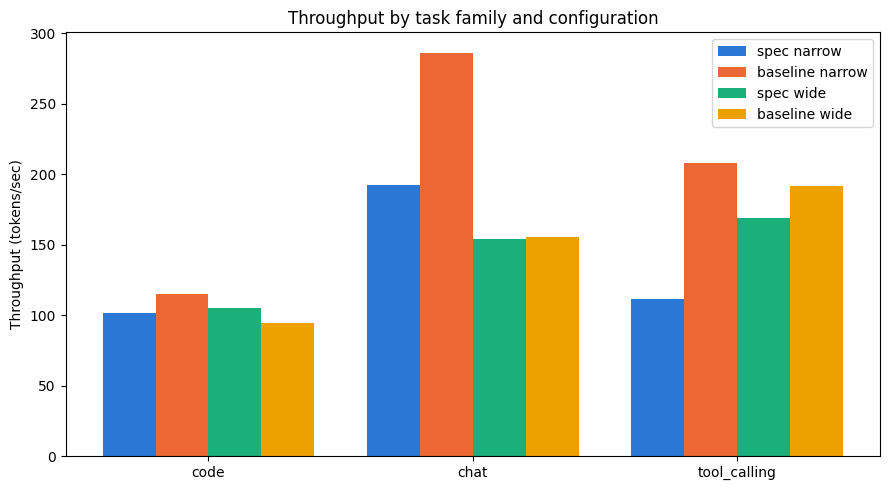

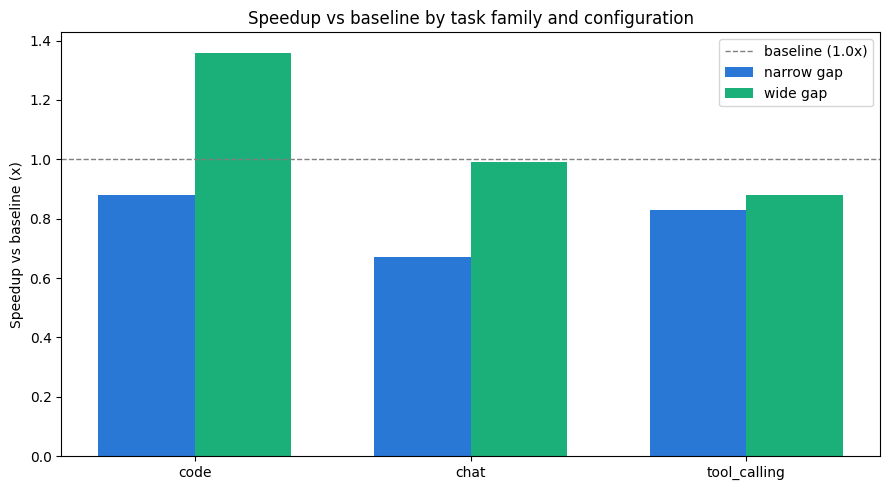

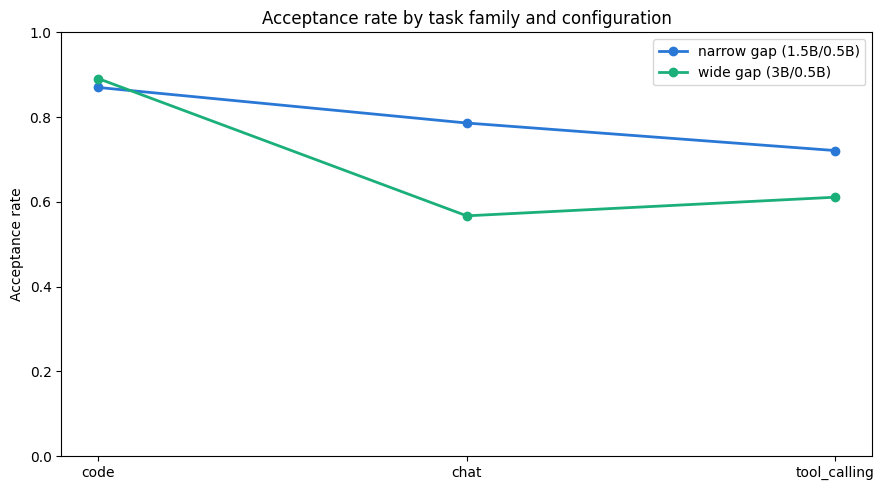

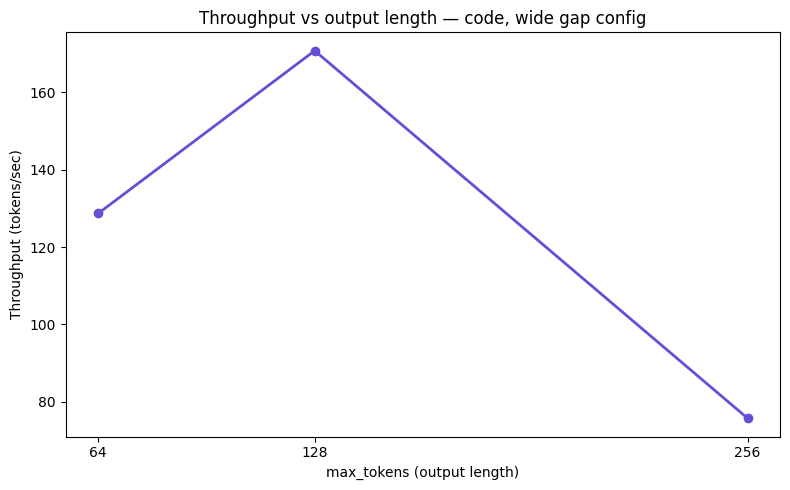

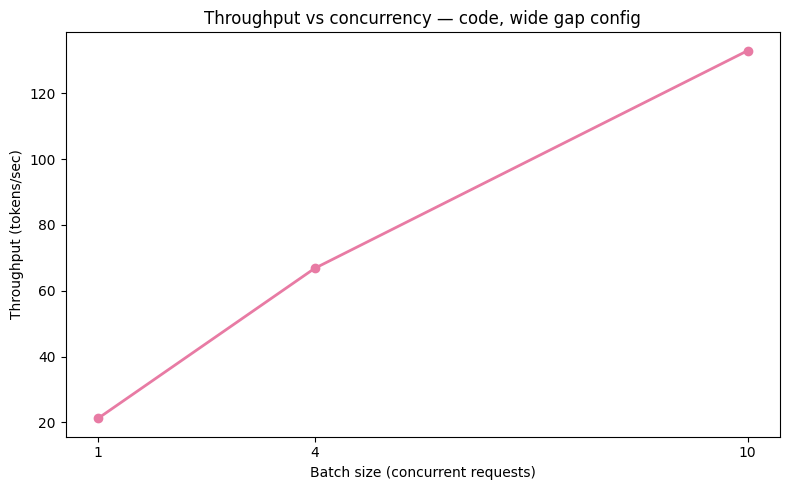

Saved: chart_throughput.png, chart_speedup.png, chart_acceptance.png, chart_osl_sweep.png, chart_concurrency_sweep.png


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data from your runs ---
task_families = ["code", "chat", "tool_calling"]

spec_narrow = [101.5, 192.2, 111.5]
baseline_narrow = [115.1, 286.2, 207.9]
spec_wide = [104.7, 154.1, 168.7]
baseline_wide = [94.6, 155.7, 191.2]

speedup_narrow = [0.88, 0.67, 0.83]
speedup_wide = [1.36, 0.99, 0.88]

acceptance_narrow = [0.870, 0.786, 0.721]
acceptance_wide = [0.891, 0.567, 0.611]

# --- Chart 1: Grouped bar — throughput by task/config ---
x = np.arange(len(task_families))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 1.5*width, spec_narrow, width, label="spec narrow", color="#2a78d6")
ax.bar(x - 0.5*width, baseline_narrow, width, label="baseline narrow", color="#eb6834")
ax.bar(x + 0.5*width, spec_wide, width, label="spec wide", color="#1baf7a")
ax.bar(x + 1.5*width, baseline_wide, width, label="baseline wide", color="#eda100")

ax.set_xticks(x)
ax.set_xticklabels(task_families)
ax.set_ylabel("Throughput (tokens/sec)")
ax.set_title("Throughput by task family and configuration")
ax.legend()
plt.tight_layout()
plt.savefig("chart_throughput.png", dpi=150)
plt.show()

# --- Chart 2: Bar — speedup vs baseline, with reference line at 1.0 ---
fig, ax = plt.subplots(figsize=(9, 5))
x2 = np.arange(len(task_families))
width2 = 0.35

ax.bar(x2 - width2/2, speedup_narrow, width2, label="narrow gap", color="#2a78d6")
ax.bar(x2 + width2/2, speedup_wide, width2, label="wide gap", color="#1baf7a")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="baseline (1.0x)")

ax.set_xticks(x2)
ax.set_xticklabels(task_families)
ax.set_ylabel("Speedup vs baseline (x)")
ax.set_title("Speedup vs baseline by task family and configuration")
ax.legend()
plt.tight_layout()
plt.savefig("chart_speedup.png", dpi=150)
plt.show()

# --- Chart 3: Line — acceptance rate by task family, narrow vs wide ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(task_families, acceptance_narrow, marker="o", label="narrow gap (1.5B/0.5B)", color="#2a78d6", linewidth=2)
ax.plot(task_families, acceptance_wide, marker="o", label="wide gap (3B/0.5B)", color="#1baf7a", linewidth=2)

ax.set_ylabel("Acceptance rate")
ax.set_title("Acceptance rate by task family and configuration")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig("chart_acceptance.png", dpi=150)
plt.show()

# --- Chart 4: OSL sweep — TPS vs output length (code, wide gap) ---
osl_tokens = [64, 128, 256]
osl_tps = [128.7, 170.8, 75.7]  # note: 256 point likely affected by JIT/batch-tail artifact

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(osl_tokens, osl_tps, marker="o", color="#6250d6", linewidth=2)
ax.set_xlabel("max_tokens (output length)")
ax.set_ylabel("Throughput (tokens/sec)")
ax.set_title("Throughput vs output length — code, wide gap config")
ax.set_xticks(osl_tokens)
plt.tight_layout()
plt.savefig("chart_osl_sweep.png", dpi=150)
plt.show()

# --- Chart 5: Concurrency sweep — TPS vs batch size (code, wide gap) ---
batch_sizes = [1, 4, 10]
batch_tps = [21.2, 66.8, 133.0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(batch_sizes, batch_tps, marker="o", color="#e87ba4", linewidth=2)
ax.set_xlabel("Batch size (concurrent requests)")
ax.set_ylabel("Throughput (tokens/sec)")
ax.set_title("Throughput vs concurrency — code, wide gap config")
ax.set_xticks(batch_sizes)
plt.tight_layout()
plt.savefig("chart_concurrency_sweep.png", dpi=150)
plt.show()

print("Saved: chart_throughput.png, chart_speedup.png, chart_acceptance.png, chart_osl_sweep.png, chart_concurrency_sweep.png")